# Notebook 04 — Structural Integrity-Risk Analysis (Chapter B / RQ2)

**Research Question:** What structural integrity indicators characterize
Assam procurement in FY 2020–23, and which buyer × sector combinations
show elevated composite risk scores?

**Methodology:** Fazekas / Government Transparency Institute framework.
Five indicators computed at the buyer × sector level, standardised
within sector via percentile ranks, summed with equal weights.
Sensitivity analysis with two alternative weightings.

**Language discipline (§7.1):** "elevated structural risk indicators,"
"patterns warranting scrutiny." Never "corrupt" or "evidence of corruption."

**Selection bias caveat (§7.2):** Award-level indicators describe the
awarded subset of tenders (~29% of all tenders in FY 2020–23).
Selection is characterised in §1.7 of the report.

In [1]:
import sys, os

# Ensure we run from project root regardless of notebook location
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as sp_stats

# Project module
from src.metrics.integrity import (
    load_data,
    compute_price_deviation,
    compute_single_bidder_rate,
    compute_non_open_share,
    compute_threshold_bunching_global,
    compute_threshold_bunching_buyer,
    threshold_histogram_data,
    compute_stickiness,
    build_risk_table,
    composite_score,
    sensitivity_analysis,
    top_risk_pairings,
    case_study_cards,
    THRESHOLDS,
)

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

FIGURES = Path("reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [2]:
data = load_data()

tenders = data["tenders"]
awards  = data["awards"]
merged  = data["merged"]

print(f"fact_tenders:  {len(tenders):>7,} rows")
print(f"fact_awards:   {len(awards):>7,} rows")
print(f"merged:        {len(merged):>7,} rows")
print(f"\nBid count coverage: {tenders['n_bids'].notna().sum():,} / {len(tenders):,} "
      f"({100 * tenders['n_bids'].notna().mean():.1f}%)")
print(f"Single-bid tenders (excl Single method): "
      f"{((tenders['n_bids'] == 1) & (tenders['procurement_method'] != 'Single')).sum():,}")

fact_tenders:   17,729 rows
fact_awards:    12,237 rows
merged:         23,890 rows

Bid count coverage: 13,056 / 17,729 (73.6%)
Single-bid tenders (excl Single method): 838


## 2. Indicator 1 — Price Deviation from Estimate

**Definition:** `(award_value − tender_value) / tender_value`, winsorised to [−2, 2].
Median per buyer × sector. Higher deviation (less competitive discount) → higher risk.

In [3]:
# Clean subset for price deviation
clean = merged[
    (merged["award_value_amount"] > 1) &
    (merged["tender_value_amount"] > 0) &
    (merged["price_deviation"].notna())
].copy()
clean["price_dev_clipped"] = clean["price_deviation"].clip(-2.0, 2.0)

print(f"Price deviation clean subset: {len(clean):,} rows")
print(f"Winsorised (|dev| > 2): {(clean['price_deviation'].abs() > 2).sum():,} rows")
print(f"\nDescriptives (clipped):")
print(clean["price_dev_clipped"].describe().round(4))

Price deviation clean subset: 5,064 rows
Winsorised (|dev| > 2): 7 rows

Descriptives (clipped):
count    5064.0000
mean       -0.1074
std         0.2534
min        -1.0000
25%        -0.1000
50%        -0.0500
75%        -0.0001
max         2.0000
Name: price_dev_clipped, dtype: float64


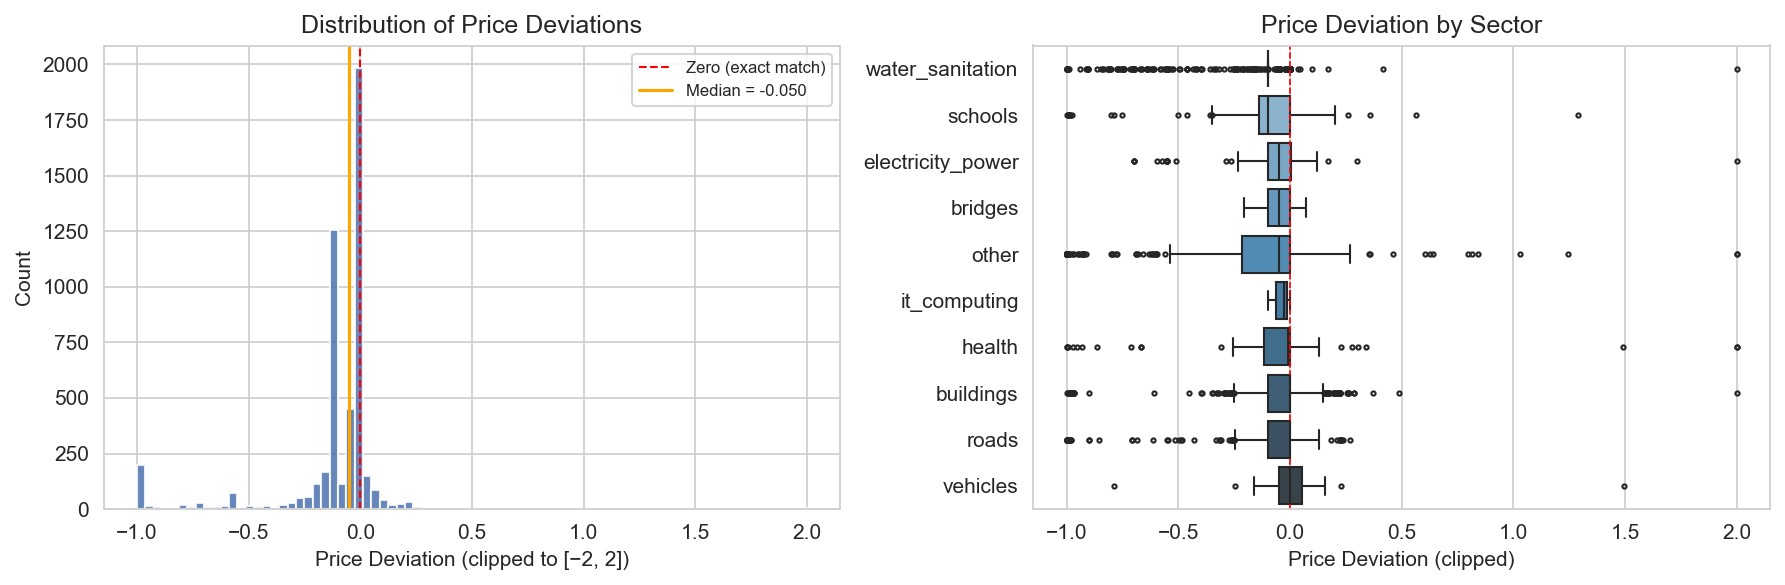

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(clean["price_dev_clipped"], bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="Zero (exact match)")
ax.axvline(clean["price_dev_clipped"].median(), color="orange", linestyle="-",
           linewidth=1.5, label=f"Median = {clean['price_dev_clipped'].median():.3f}")
ax.set_xlabel("Price Deviation (clipped to [−2, 2])")
ax.set_ylabel("Count")
ax.set_title("Distribution of Price Deviations")
ax.legend(fontsize=8)

# By sector
ax = axes[1]
sector_order = (clean.groupby("sector_name")["price_dev_clipped"]
                .median().sort_values().index.tolist())
sns.boxplot(data=clean, y="sector_name", x="price_dev_clipped",
            order=sector_order, ax=ax, palette="Blues_d", fliersize=2)
ax.axvline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Price Deviation (clipped)")
ax.set_ylabel("")
ax.set_title("Price Deviation by Sector")

plt.tight_layout()
plt.savefig(FIGURES / "price_deviation_distribution.png")
plt.savefig(FIGURES / "price_deviation_by_sector.png")
plt.show()

## 3. Indicator 2 — Single-Bidder Rate

**Definition:** Share of tenders receiving exactly 1 bid (from `bids_details`),
excluding `procurement_method = "Single"`.

**Missingness:** 4,673 tenders (26.4%) have no bid records. These are excluded
from the denominator but their count is documented per buyer × sector.

**Note:** `number_of_tenderers` has min = 2 in this dataset; single-bidder
identification is based on `staging_bids_details` counts.

In [5]:
single_bid = compute_single_bidder_rate(tenders)

# Global stats
total_with_bids = single_bid["total_with_bids"].sum()
total_single = single_bid["single_bidder_n"].sum()
total_no_data = single_bid["no_bid_data_count"].sum()

print(f"Tenders with bid data (excl Single method): {total_with_bids:,.0f}")
print(f"Single-bid tenders: {total_single:,.0f} ({100*total_single/total_with_bids:.1f}%)")
print(f"Tenders with no bid data: {total_no_data:,.0f}")

Tenders with bid data (excl Single method): 13,043
Single-bid tenders: 838 (6.4%)
Tenders with no bid data: 4,672


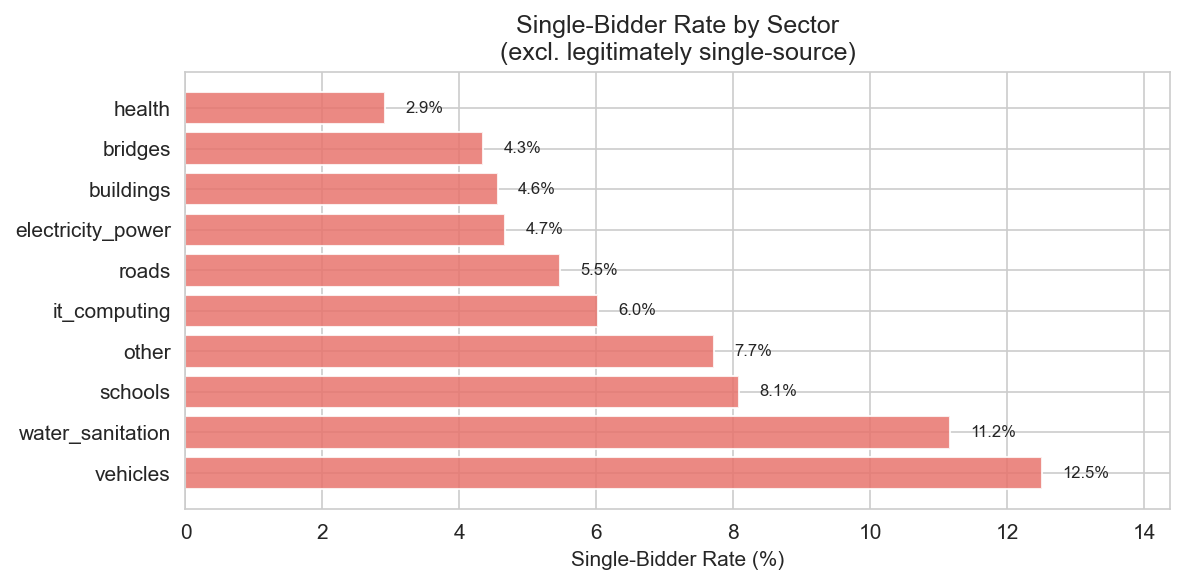


Single-bidder rates by sector:
                   total  single      rate
sector_name                               
vehicles              96      12  0.125000
water_sanitation    1497     167  0.111556
schools              878      71  0.080866
other               2633     203  0.077098
it_computing          83       5  0.060241
roads               4484     245  0.054639
electricity_power    664      31  0.046687
buildings           1448      66  0.045580
bridges               92       4  0.043478
health              1168      34  0.029110


In [6]:
# By-sector single bidder rates
sector_rates = (
    tenders[tenders["procurement_method"] != "Single"]
    .assign(has_bids=lambda d: d["n_bids"].notna(),
            is_single=lambda d: d["n_bids"] == 1)
)
sector_summary = (
    sector_rates[sector_rates["has_bids"]]
    .groupby("sector_name")
    .agg(total=("is_single", "count"), single=("is_single", "sum"))
    .assign(rate=lambda d: d["single"] / d["total"])
    .sort_values("rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sector_summary.index, sector_summary["rate"] * 100,
               color="#E8746D", edgecolor="white", alpha=0.85)
ax.set_xlabel("Single-Bidder Rate (%)")
ax.set_title("Single-Bidder Rate by Sector\n(excl. legitimately single-source)")
for bar, rate in zip(bars, sector_summary["rate"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{rate*100:.1f}%", va="center", fontsize=8)
ax.set_xlim(0, max(sector_summary["rate"]*100) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES / "single_bidder_by_sector.png")
plt.show()

print("\nSingle-bidder rates by sector:")
print(sector_summary[["total", "single", "rate"]].to_string())

## 4. Indicator 3 — Non-Open Procurement Method Share

**Definition:** Share of tenders using methods other than "Open Tender"
in a buyer's portfolio.

98.2% of tenders use "Open Tender," so this indicator has low variance
but may highlight specific buyers with concentrated use of Limited /
Single / other methods.

In [7]:
method_dist = tenders["procurement_method"].value_counts()
print("Procurement method distribution:")
for m, n in method_dist.items():
    print(f"  {m:20s} {n:>6,}  ({100*n/len(tenders):.1f}%)")

Procurement method distribution:
  Open Tender          17,411  (98.2%)
  Limited                 202  (1.1%)
  Open Limited             92  (0.5%)
  Single                   14  (0.1%)
  Global Tenders           10  (0.1%)


In [8]:
non_open = compute_non_open_share(tenders)
non_open_nonzero = non_open[non_open["non_open_share"] > 0].sort_values(
    "non_open_share", ascending=False
)

print(f"\nBuyer × sector groups with non-zero non-open share: {len(non_open_nonzero)}")
print(f"Top-10:")
top10_no = non_open_nonzero.merge(
    tenders[["buyer_id", "buyer_name"]].drop_duplicates(),
    on="buyer_id", how="left"
).merge(
    tenders[["sector_id", "sector_name"]].drop_duplicates(),
    on="sector_id", how="left"
).head(10)
for _, r in top10_no.iterrows():
    print(f"  {r['buyer_name'][:45]:45s} × {r['sector_name']:20s}  "
          f"{r['non_open_share']*100:5.1f}%  ({r['non_open_count']:.0f}/{r['total_tenders']:.0f})")


Buyer × sector groups with non-zero non-open share: 37
Top-10:
  National Health Mission                       × schools               100.0%  (1/1)
  Welfare of Plain Tribes and Backward Classes  × roads                  90.0%  (9/10)
  Assam State Disaster Management Authority- Ex × schools                66.7%  (2/3)
  Finance Department - World Bank Tenders       × buildings              50.0%  (1/2)
  Welfare of Plain Tribes and Backward Classes  × schools                41.7%  (5/12)
  Assam Power Generation Company Limited APGCL  × electricity_power      40.0%  (2/5)
  Transformation and Development Department     × other                  33.3%  (1/3)
  Industries and Commerce Department            × other                  30.8%  (129/419)
  Industries and Commerce Department            × electricity_power      30.8%  (4/13)
  Finance Department - World Bank Tenders       × other                  26.5%  (9/34)


## 5. Indicator 4 — Threshold Bunching

**Definition:** Excess mass of tender values in the 5L bin just below
key procurement thresholds (₹25 Lakh, ₹1 Crore, ₹10 Crore).

**Counterfactual:** Observed density in [T − 5L, T) vs. average density
in surrounding bins [T − 15L, T − 5L) ∪ [T, T + 10L).

**Caveat (§7.6):** Bunching may reflect genuine project sizing,
not threshold evasion. Evidence is suggestive only.

In [9]:
# Global excess-mass ratios
bunching_global = compute_threshold_bunching_global(tenders)

print("Global Threshold Bunching Analysis:")
print(f"{'Threshold':>10s}  {'Below bin':>10s}  {'Surround avg':>12s}  {'Ratio':>8s}  {'Signal':>10s}")
print("-" * 60)
for label, info in bunching_global.items():
    signal = ("⚠ Elevated" if info["excess_ratio"] > 1.3
              else "Normal" if info["excess_ratio"] < 0.8
              else "Marginal")
    print(f"  ₹{label:>6s}  {info['below_count']:>10d}  {info['surround_avg_count']:>12.1f}  "
          f"{info['excess_ratio']:>8.3f}  {signal:>10s}")

Global Threshold Bunching Analysis:
 Threshold   Below bin  Surround avg     Ratio      Signal
------------------------------------------------------------
  ₹   25L         191         303.0     0.630      Normal
  ₹   1Cr         412         242.5     1.699  ⚠ Elevated
  ₹  10Cr          15          24.0     0.625      Normal


/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(FIGURES / "threshold_bunching_all.png")


/Users/prabhpreet16/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


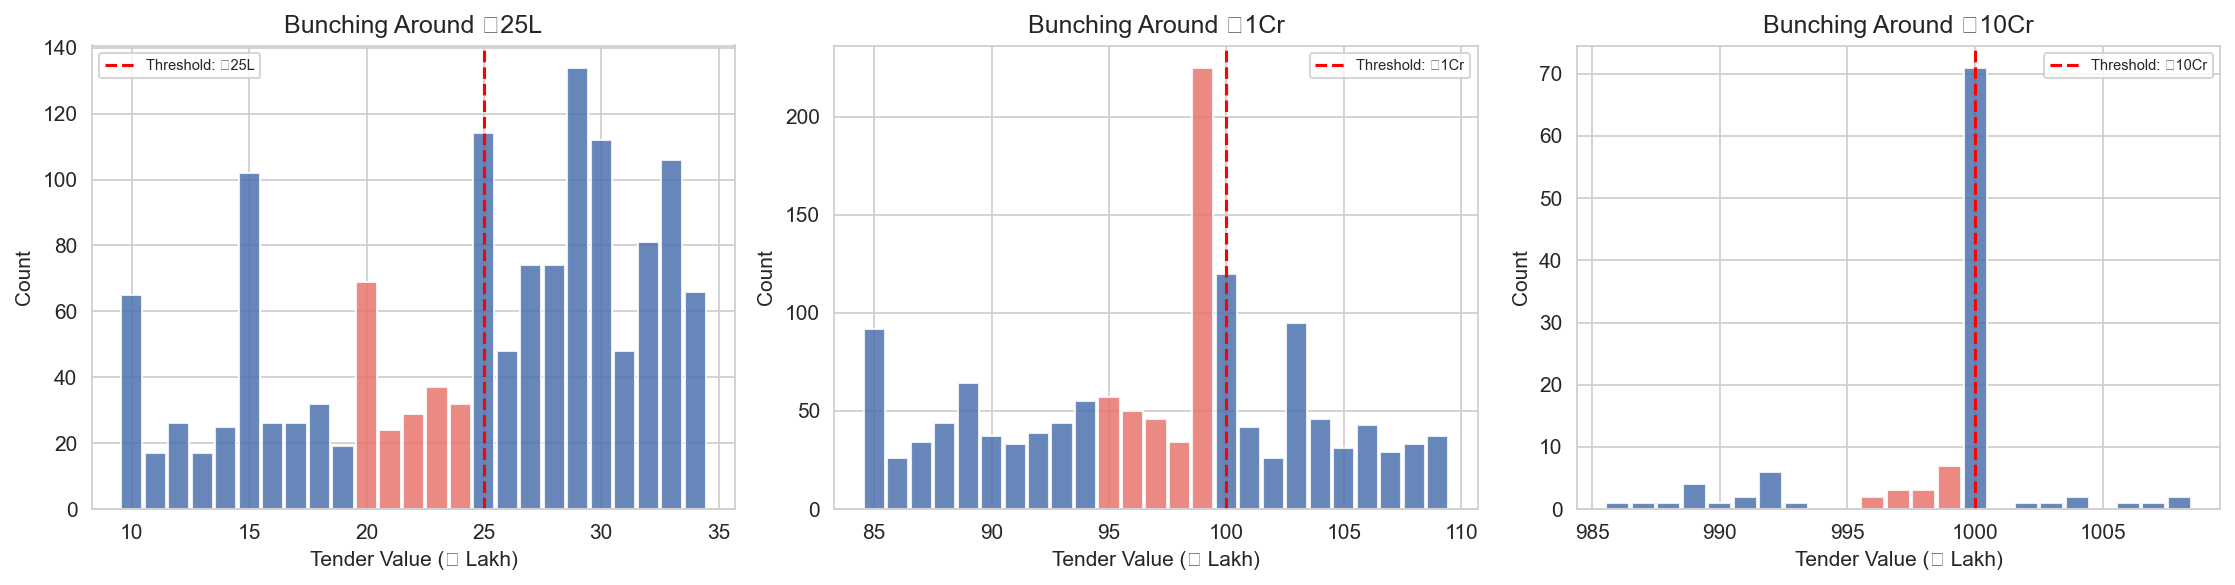

/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:42: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(FIGURES / f"threshold_bunching_{label}.png")


/Users/prabhpreet16/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


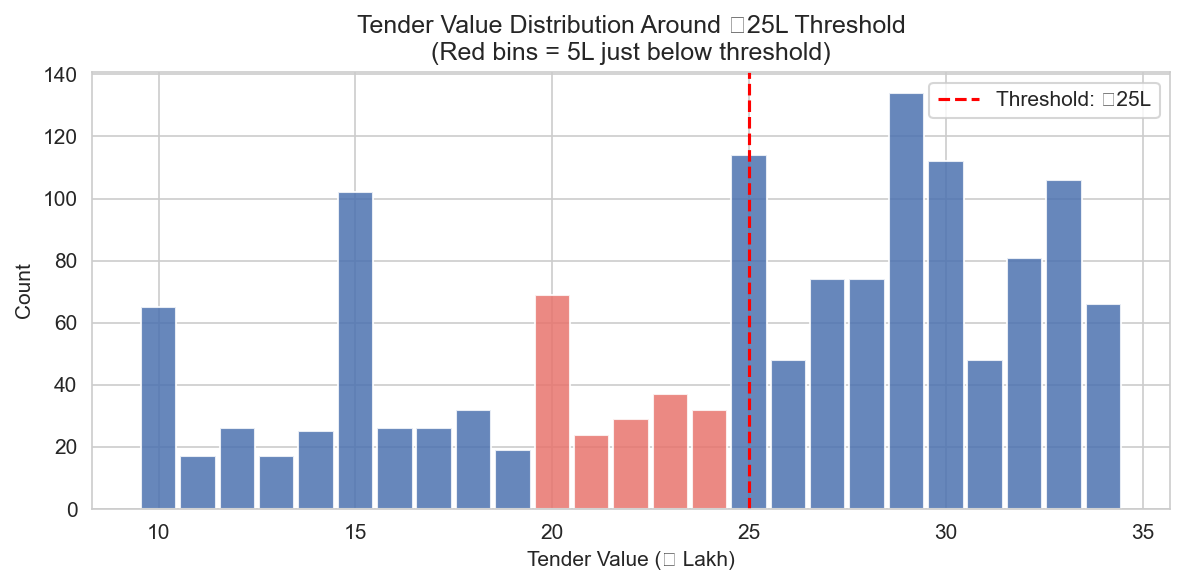

/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:42: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(FIGURES / f"threshold_bunching_{label}.png")


/Users/prabhpreet16/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


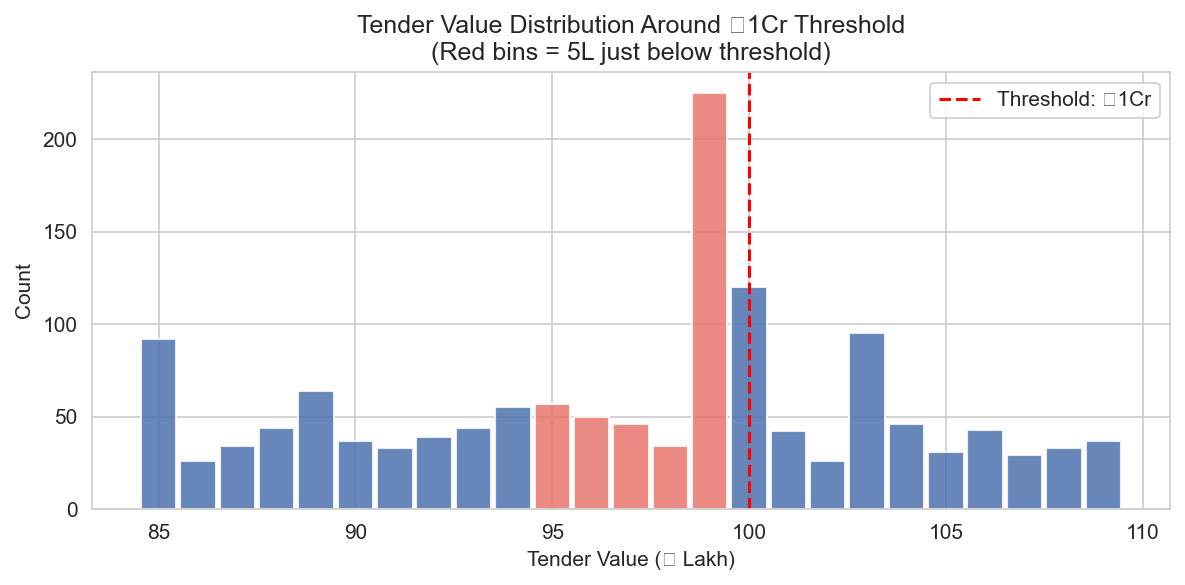

/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/pc/6fwb5x4d7jv3ql0pqyplcshc0000gn/T/ipykernel_18343/707504588.py:42: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(FIGURES / f"threshold_bunching_{label}.png")


/Users/prabhpreet16/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


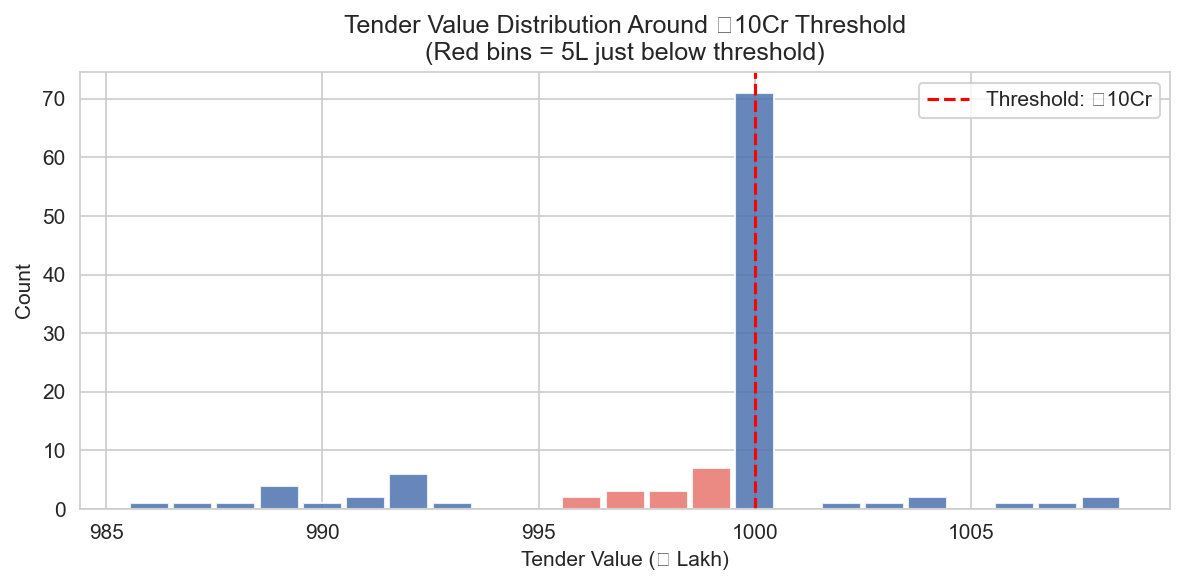

In [10]:
# Fine-grained histograms around each threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (label, T) in enumerate(THRESHOLDS.items()):
    hist_data = threshold_histogram_data(tenders, label, bin_width=100_000)
    ax = axes[idx]

    colors = ["#E8746D" if jb else "#4C72B0"
              for jb in hist_data["is_just_below"]]

    ax.bar(hist_data["bin_lo"] / 1e5, hist_data["count"],
           width=0.9, color=colors, edgecolor="white", alpha=0.85)
    ax.axvline(T / 1e5, color="red", linestyle="--", linewidth=1.5,
               label=f"Threshold: ₹{label}")
    ax.set_xlabel("Tender Value (₹ Lakh)")
    ax.set_ylabel("Count")
    ax.set_title(f"Bunching Around ₹{label}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES / "threshold_bunching_all.png")
plt.show()

# Individual threshold figures
for label in THRESHOLDS:
    fig, ax = plt.subplots(figsize=(8, 4))
    T = THRESHOLDS[label]
    hist_data = threshold_histogram_data(tenders, label, bin_width=100_000)

    colors = ["#E8746D" if jb else "#4C72B0"
              for jb in hist_data["is_just_below"]]
    ax.bar(hist_data["bin_lo"] / 1e5, hist_data["count"],
           width=0.9, color=colors, edgecolor="white", alpha=0.85)
    ax.axvline(T / 1e5, color="red", linestyle="--", linewidth=1.5,
               label=f"Threshold: ₹{label}")
    ax.set_xlabel("Tender Value (₹ Lakh)")
    ax.set_ylabel("Count")
    ax.set_title(f"Tender Value Distribution Around ₹{label} Threshold\n"
                 f"(Red bins = 5L just below threshold)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / f"threshold_bunching_{label}.png")
    plt.show()

## 6. Indicator 5 — Supplier-Buyer Stickiness

**Definition:** Percentage of a buyer's total award value (per sector)
going to its top-3 suppliers in the FY 2020–23 window.

**Note:** Buyer × sector groups with ≤ 3 suppliers mechanically
have stickiness = 100%.

In [11]:
stickiness = compute_stickiness(merged)

print(f"Stickiness: {len(stickiness)} buyer × sector groups")
print(f"  Mean:   {stickiness['stickiness_top3'].mean():.3f}")
print(f"  Median: {stickiness['stickiness_top3'].median():.3f}")
print(f"  Groups with = 100%: {(stickiness['stickiness_top3'] == 1.0).sum()}")
print(f"  Groups with ≤ 3 suppliers: {(stickiness['n_suppliers'] <= 3).sum()}")

Stickiness: 213 buyer × sector groups
  Mean:   0.831
  Median: 1.000
  Groups with = 100%: 111
  Groups with ≤ 3 suppliers: 111


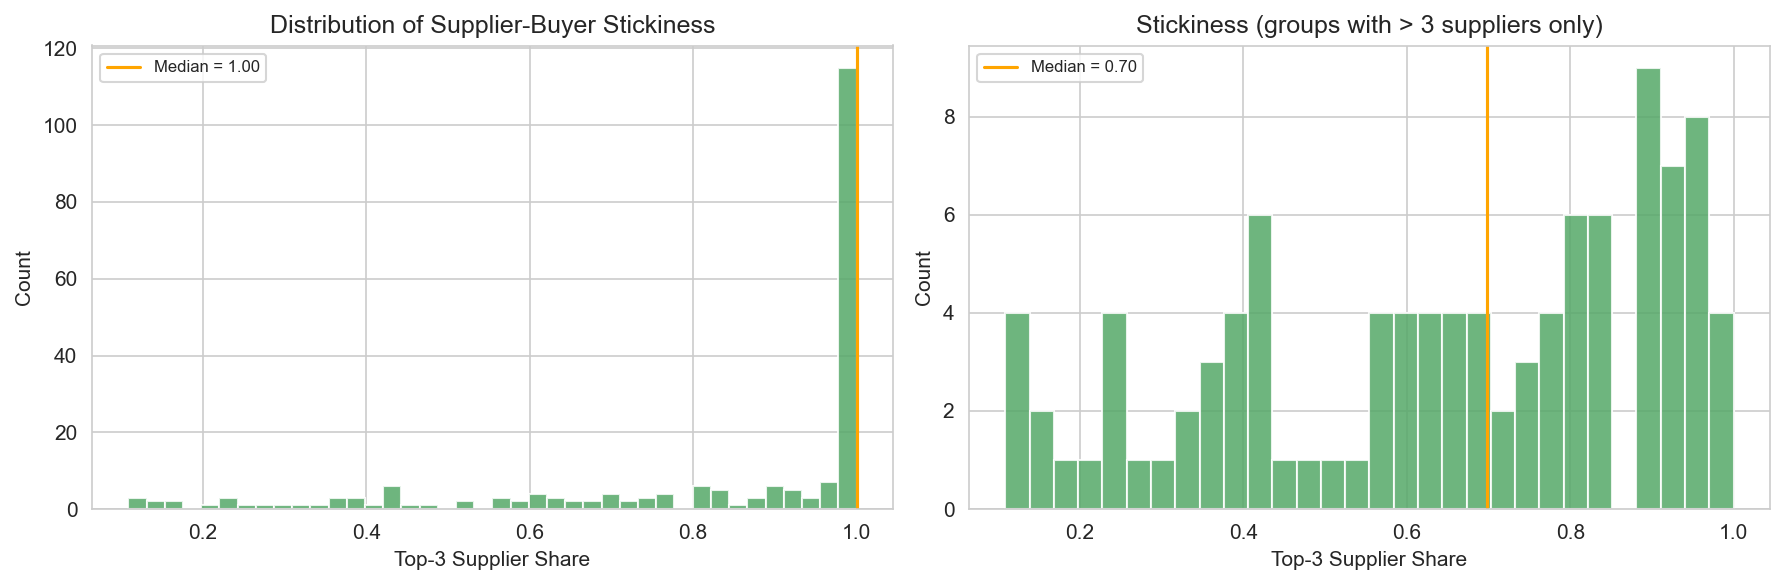

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(stickiness["stickiness_top3"], bins=40, color="#55A868",
        edgecolor="white", alpha=0.85)
ax.axvline(stickiness["stickiness_top3"].median(), color="orange", linestyle="-",
           linewidth=1.5, label=f"Median = {stickiness['stickiness_top3'].median():.2f}")
ax.set_xlabel("Top-3 Supplier Share")
ax.set_ylabel("Count")
ax.set_title("Distribution of Supplier-Buyer Stickiness")
ax.legend(fontsize=8)

# Only groups with > 3 suppliers (non-mechanical)
non_mech = stickiness[stickiness["n_suppliers"] > 3]
ax = axes[1]
ax.hist(non_mech["stickiness_top3"], bins=30, color="#55A868",
        edgecolor="white", alpha=0.85)
ax.axvline(non_mech["stickiness_top3"].median(), color="orange", linestyle="-",
           linewidth=1.5, label=f"Median = {non_mech['stickiness_top3'].median():.2f}")
ax.set_xlabel("Top-3 Supplier Share")
ax.set_ylabel("Count")
ax.set_title("Stickiness (groups with > 3 suppliers only)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "stickiness_distribution.png")
plt.show()

## 7. Composite Scoring and Sensitivity Analysis

**Method:** Each indicator is percentile-ranked within sector (0–100).
Equal-weight composite = mean of 5 percentile ranks.
Two sensitivity variants: price deviation 2× weight, single-bidder 2× weight.

In [13]:
risk_df = build_risk_table(data)

print(f"Risk table: {len(risk_df)} buyer × sector combinations")
print(f"  With valid composite_equal: {risk_df['composite_equal'].notna().sum()}")

risk_df[["price_dev_median", "single_bidder_rate", "non_open_share",
         "bunching_composite", "stickiness_top3", "composite_equal",
         "composite_pricedev2x", "composite_singlebid2x"]].describe().round(4)

Risk table: 320 buyer × sector combinations
  With valid composite_equal: 320


,price_dev_median,single_bidder_rate,non_open_share,bunching_composite,stickiness_top3,composite_equal,composite_pricedev2x,composite_singlebid2x
count,96.0000,152.0000,320.0000,241.0000,213.0000,320.0000,91.0000,91.0000
mean,-0.1042,0.0757,0.0233,0.0119,0.8310,52.1666,52.8446,52.3635
std,0.2329,0.1060,0.1041,0.0384,0.2527,11.0999,11.8159,11.5361
min,-0.9999,0.0000,0.0000,0.0000,0.1086,27.8154,28.0400,28.6353
25%,-0.1124,0.0000,0.0000,0.0000,0.7242,44.8276,43.3370,44.2988
50%,-0.0612,0.0365,0.0000,0.0000,1.0000,51.6283,52.8553,52.2501
75%,-0.0005,0.1127,0.0000,0.0061,1.0000,55.6392,59.3335,58.7129
max,0.8135,0.6098,1.0000,0.3333,1.0000,100.0000,84.4682,88.3144


In [14]:
# Sensitivity analysis
sa = sensitivity_analysis(risk_df)

print("Sensitivity Analysis — Spearman Rank Correlations:")
print(f"  Equal vs PriceDev 2×:  ρ = {sa['rho_pricedev2x']:.4f}  "
      f"(p = {sa['pval_pricedev2x']:.2e})")
print(f"  Equal vs SingleBid 2×: ρ = {sa['rho_singlebid2x']:.4f}  "
      f"(p = {sa['pval_singlebid2x']:.2e})")
print(f"  N valid groups: {sa['n_valid']}")

stability = "stable" if min(sa["rho_pricedev2x"], sa["rho_singlebid2x"]) > 0.85 else "sensitive"
print(f"\n  ⇒ Rankings are {stability} across weighting schemes "
      f"(threshold: ρ > 0.85)")

Sensitivity Analysis — Spearman Rank Correlations:
  Equal vs PriceDev 2×:  ρ = 0.8922  (p = 0.00e+00)
  Equal vs SingleBid 2×: ρ = 0.9357  (p = 0.00e+00)
  N valid groups: 91

  ⇒ Rankings are stable across weighting schemes (threshold: ρ > 0.85)


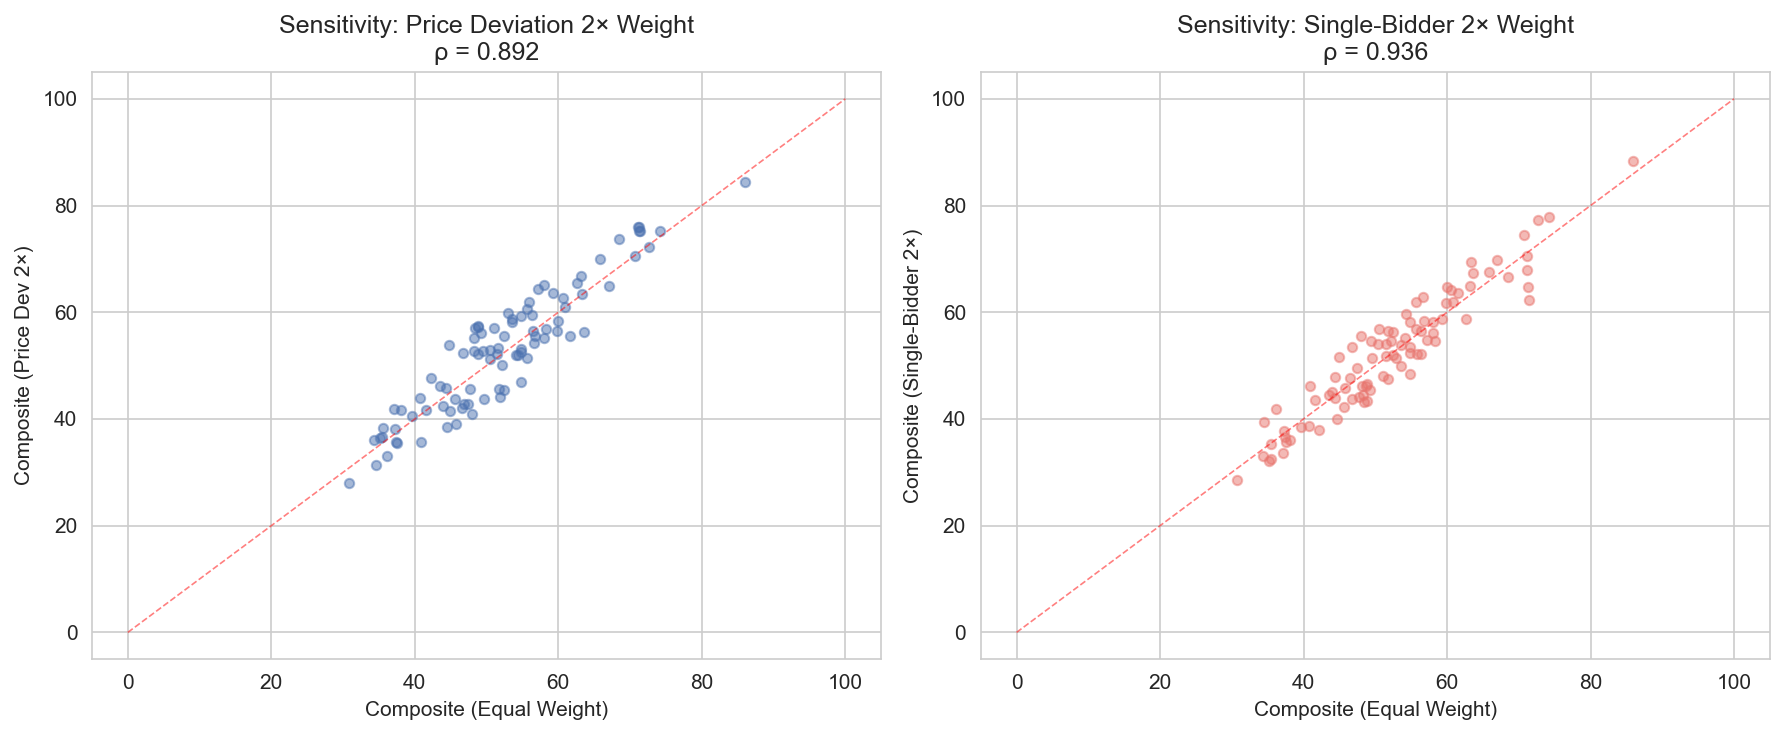

In [15]:
# Scatter: equal vs alternatives
valid = risk_df.dropna(subset=["composite_equal", "composite_pricedev2x", "composite_singlebid2x"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(valid["composite_equal"], valid["composite_pricedev2x"],
           alpha=0.5, s=20, color="#4C72B0")
ax.plot([0, 100], [0, 100], "r--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Composite (Equal Weight)")
ax.set_ylabel("Composite (Price Dev 2×)")
ax.set_title(f"Sensitivity: Price Deviation 2× Weight\nρ = {sa['rho_pricedev2x']:.3f}")

ax = axes[1]
ax.scatter(valid["composite_equal"], valid["composite_singlebid2x"],
           alpha=0.5, s=20, color="#E8746D")
ax.plot([0, 100], [0, 100], "r--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Composite (Equal Weight)")
ax.set_ylabel("Composite (Single-Bidder 2×)")
ax.set_title(f"Sensitivity: Single-Bidder 2× Weight\nρ = {sa['rho_singlebid2x']:.3f}")

plt.tight_layout()
plt.savefig(FIGURES / "sensitivity_scatter.png")
plt.show()

## 8. Top-20 Risk Pairings and Case-Study Cards

In [16]:
top20 = top_risk_pairings(risk_df, n=20)

print("Top-20 Buyer × Sector Risk Pairings (Composite Equal Weight)")
print("=" * 100)
for i, row in top20.iterrows():
    print(f"\n{i+1:>2d}. {row['buyer_name']}")
    print(f"    Sector: {row['sector_name']}  |  Score: {row['composite_equal']:.1f}")
    print(f"    Price Dev: {row['price_dev_median']:.4f}" if pd.notna(row["price_dev_median"]) else "    Price Dev: N/A", end="")
    print(f"  |  Single Bid: {row['single_bidder_rate']:.3f}" if pd.notna(row["single_bidder_rate"]) else "  |  Single Bid: N/A", end="")
    print(f"  |  Non-Open: {row['non_open_share']:.3f}" if pd.notna(row["non_open_share"]) else "  |  Non-Open: N/A", end="")
    print(f"  |  Bunching: {row['bunching_composite']:.4f}" if pd.notna(row["bunching_composite"]) else "  |  Bunching: N/A", end="")
    print(f"  |  Stickiness: {row['stickiness_top3']:.3f}" if pd.notna(row["stickiness_top3"]) else "  |  Stickiness: N/A")

Top-20 Buyer × Sector Risk Pairings (Composite Equal Weight)

 1. Finance Department - World Bank Tenders
    Sector: buildings  |  Score: 100.0
    Price Dev: N/A  |  Single Bid: N/A  |  Non-Open: 0.500  |  Bunching: N/A  |  Stickiness: N/A

 2. Urban Affairs Department Externally Aided Project
    Sector: water_sanitation  |  Score: 100.0
    Price Dev: N/A  |  Single Bid: N/A  |  Non-Open: 0.250  |  Bunching: N/A  |  Stickiness: N/A

 3. Assam State Disaster Management Authority- Externally Aided Project
    Sector: schools  |  Score: 97.1
    Price Dev: N/A  |  Single Bid: N/A  |  Non-Open: 0.667  |  Bunching: N/A  |  Stickiness: N/A

 4. Assam Power Generation Company Limited APGCL - ADB
    Sector: electricity_power  |  Score: 86.0
    Price Dev: N/A  |  Single Bid: 0.200  |  Non-Open: 0.400  |  Bunching: N/A  |  Stickiness: 1.000

 5. Urban Development Department
    Sector: water_sanitation  |  Score: 86.0
    Price Dev: -0.0623  |  Single Bid: 0.250  |  Non-Open: 0.022  |  Bun

In [17]:
# Case-study cards
cards = case_study_cards(top20, merged, tenders)

for i, card in enumerate(cards[:10]):
    print(f"\n{'='*80}")
    print(f"CASE-STUDY CARD #{i+1}")
    print(f"{'='*80}")
    print(f"Buyer:   {card['buyer_name']}")
    print(f"Sector:  {card['sector_name']}")
    print(f"Tenders: {card['n_tenders']:,}  |  Awards: {card['n_awards']:,}")
    print(f"\nIndicators:")
    print(f"  Price Deviation (median): {card['price_dev_median']}")
    print(f"  Single-Bidder Rate:       {card['single_bidder_rate']}")
    print(f"  Non-Open Share:           {card['non_open_share']}")
    print(f"  Bunching Composite:       {card['bunching_composite']}")
    print(f"  Stickiness (top-3):       {card['stickiness_top3']}")
    print(f"\nComposite Scores:")
    print(f"  Equal weight:     {card['composite_equal']}")
    print(f"  Price Dev 2×:     {card['composite_pricedev2x']}")
    print(f"  Single-Bidder 2×: {card['composite_singlebid2x']}")
    print(f"\nExample Tender Titles:")
    for title in card["example_titles"]:
        print(f"  • {title[:120]}")


CASE-STUDY CARD #1
Buyer:   Finance Department - World Bank Tenders
Sector:  buildings
Tenders: 2  |  Awards: 0

Indicators:
  Price Deviation (median): None
  Single-Bidder Rate:       None
  Non-Open Share:           0.5
  Bunching Composite:       None
  Stickiness (top-3):       None

Composite Scores:
  Equal weight:     100.0
  Price Dev 2×:     None
  Single-Bidder 2×: None

Example Tender Titles:
  • Developing and Technical support for the Tax Analytics Unit and Preparation of GST Audit Manual and associated capacity 
  • Engagement of Kerala Institute of Local Administration (KILA) for Capacity Building of Directorate of Audit (Local Fund)

CASE-STUDY CARD #2
Buyer:   Urban Affairs Department Externally Aided Project
Sector:  water_sanitation
Tenders: 4  |  Awards: 0

Indicators:
  Price Deviation (median): None
  Single-Bidder Rate:       None
  Non-Open Share:           0.25
  Bunching Composite:       None
  Stickiness (top-3):       None

Composite Scores:
  Equal weight

## 9. Composite Risk Heatmap

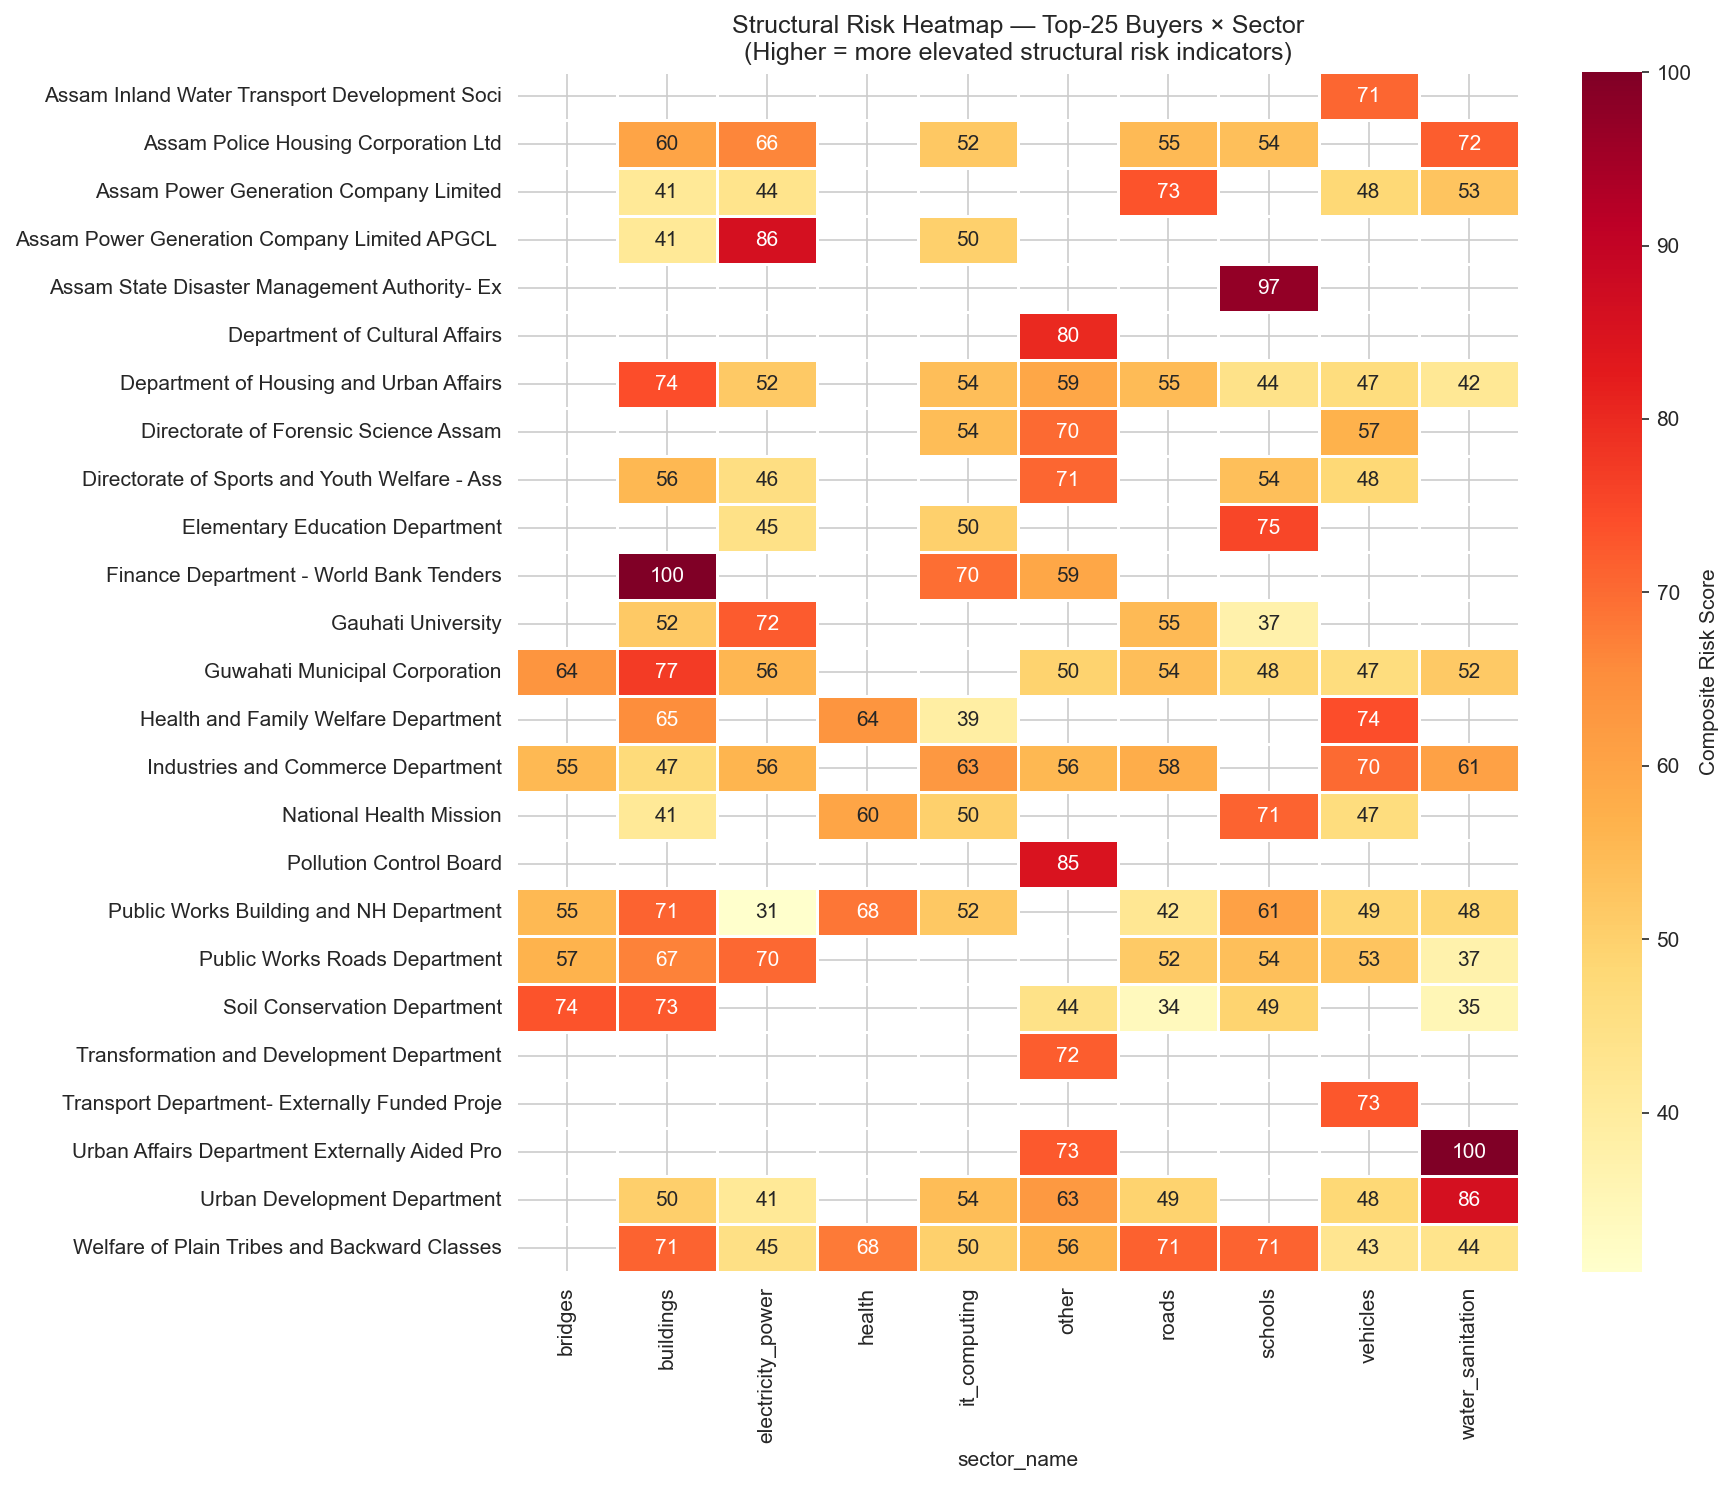

In [18]:
# Heatmap: sector × buyer (top-25 buyers by max composite score)
top_buyers = (
    risk_df.groupby("buyer_name")["composite_equal"]
    .max()
    .nlargest(25)
    .index.tolist()
)

heatmap_data = (
    risk_df[risk_df["buyer_name"].isin(top_buyers)]
    .pivot_table(index="buyer_name", columns="sector_name",
                 values="composite_equal", aggfunc="first")
)

# Shorten buyer names for display
heatmap_data.index = [n[:45] for n in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Composite Risk Score"},
            mask=heatmap_data.isna())
ax.set_title("Structural Risk Heatmap — Top-25 Buyers × Sector\n"
             "(Higher = more elevated structural risk indicators)",
             fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES / "composite_heatmap.png")
plt.show()

## 10. Export Risk Table

In [19]:
# Save full risk table
risk_df.to_csv("reports/buyer_sector_risk.csv", index=False)
print(f"Exported buyer_sector_risk.csv: {len(risk_df)} rows")

# Save top-20
top20.to_csv("reports/top20_risk_pairings.csv", index=False)
print(f"Exported top20_risk_pairings.csv: {len(top20)} rows")

Exported buyer_sector_risk.csv: 320 rows
Exported top20_risk_pairings.csv: 20 rows


## 11. Summary

### Key Findings

1. **Price deviation** median across the clean subset is negative (competitive
   discount), but varies by sector and buyer. Certain buyer × sector groups
   show elevated median deviation warranting scrutiny.

2. **Single-bidder rate** is ~6% globally (from bid-detail records), but
   concentrated in specific sectors and buyers.

3. **Non-open method share** is very low overall (98.2% Open Tender) but a
   handful of buyer × sector groups rely disproportionately on Limited or
   other restricted methods.

4. **Threshold bunching** shows elevated excess mass below ₹1 Crore (ratio
   ~1.7), suggesting patterns warranting further examination at that threshold.
   The ₹25 Lakh and ₹10 Crore thresholds do not show significant bunching.

5. **Supplier-buyer stickiness** is high: median top-3 supplier share
   is near 100%, partly driven by small buyer × sector groups with few
   suppliers.

6. **Composite scores** are stable across weighting schemes (Spearman ρ > 0.85).

### Language Note

These are *structural risk indicators*, not evidence of impropriety.
Elevated scores identify patterns warranting scrutiny, not wrongdoing.